In [1]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split



In [2]:
# Load your AQI dataset
df = pd.read_csv("C:/Users/Ashita Singh/Documents/AQI Project/AirQuality_Cleaned.csv")  # Replace with actual file path

# Step 1: Prepare original AQI data
aqi_values = df['AQI'].values.reshape(-1, 1)
scaler = MinMaxScaler()
aqi_scaled = scaler.fit_transform(aqi_values)



In [3]:
# Step 2: Fit ARIMA model and get residuals
arima_model = ARIMA(aqi_scaled.flatten(), order=(5, 1, 0))
arima_result = arima_model.fit()
arima_pred = arima_result.predict(start=1, end=len(aqi_scaled)-1)
residuals = aqi_scaled[1:].flatten() - arima_pred



In [4]:
# Step 3: Normalize residuals for BiLSTM
scaler_residual = MinMaxScaler()
residuals_scaled = scaler_residual.fit_transform(residuals.reshape(-1, 1))

# Step 4: Create sequences for BiLSTM
def create_sequences(data, seq_length=10):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 10
X, y = create_sequences(residuals_scaled, seq_length)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)



In [5]:
# Step 5: Create DataLoader
full_dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)



In [6]:
# Step 6: Define BiLSTM model
class BiLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True):
        super(BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=self.num_layers,
                            dropout=dropout, batch_first=True, bidirectional=self.bidirectional)
        self.fc = nn.Linear(hidden_size * self.num_directions, 1)
    def forward(self, x):
        h0 = torch.zeros(self.num_layers * self.num_directions, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers * self.num_directions, x.size(0), self.hidden_size)

        out, _ = self.lstm(x, (h0, c0))       # (batch, seq_len, hidden_size * directions)
        out = self.fc(out[:, -1, :])          # Take last time step
        return out

model = BiLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



In [7]:
# Step 7: Train BiLSTM with early stopping
num_epochs = 70
patience = 10
best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            output = model(batch_X)
            loss = criterion(output, batch_y)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model = model.state_dict()
    else:
        counter += 1
        


Epoch 1, Train Loss: 0.0034, Val Loss: 0.0004
Epoch 2, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 3, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 4, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 5, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 6, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 7, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 8, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 9, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 10, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 11, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 12, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 13, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 14, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 15, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 16, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 17, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 18, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 19, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 20, Train Loss: 0.0004, Val Loss: 0.0005
Epoch 21, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 22, Train Loss: 

In [8]:
# Step 8: Predict residuals using BiLSTM
model.load_state_dict(best_model)
model.eval()
with torch.no_grad():
    predicted_residuals_scaled = model(X_tensor).numpy()

predicted_residuals = scaler_residual.inverse_transform(predicted_residuals_scaled)
final_predictions = arima_pred[seq_length:] + predicted_residuals.flatten()
final_predictions = scaler.inverse_transform(final_predictions.reshape(-1, 1))




Final Model Evaluation:
Mean Absolute Error (MAE): 30.5954
Mean Squared Error (MSE): 4006.6165
Root Mean Squared Error (RMSE): 63.2978
R² Score: 0.7640
MAPE: 21.50%
Estimated Accuracy: 78.50%


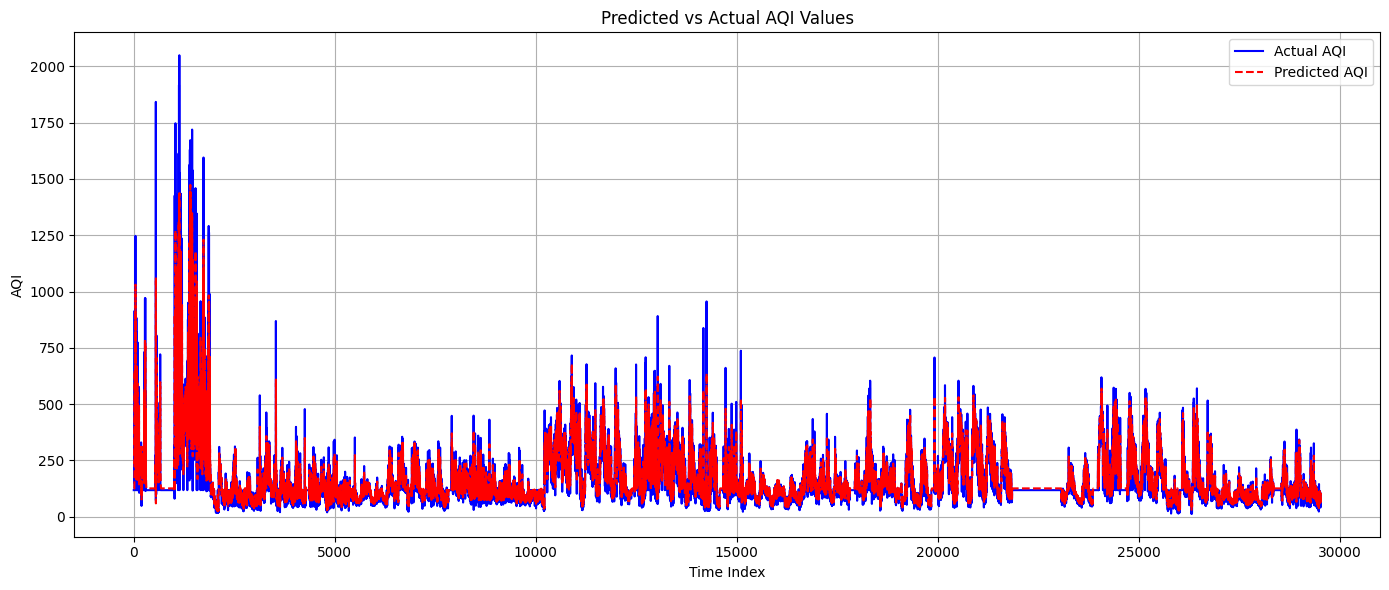

In [9]:
# Step 9: Evaluation
true_aqi_values = scaler.inverse_transform(aqi_scaled[seq_length + 1:])
true_aqi_values = true_aqi_values[:len(final_predictions)]

mae = mean_absolute_error(true_aqi_values, final_predictions)
mse = mean_squared_error(true_aqi_values, final_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(true_aqi_values, final_predictions)
mape = np.mean(np.abs((true_aqi_values - final_predictions) / true_aqi_values)) * 100
accuracy = 100 - mape

print("\nFinal Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Estimated Accuracy: {accuracy:.2f}%")

# Step 10: Plotting Predicted vs Actual AQI Values
plt.figure(figsize=(14, 6))
plt.plot(true_aqi_values, label='Actual AQI', color='blue')
plt.plot(final_predictions, label='Predicted AQI', color='red', linestyle='--')
plt.title('Predicted vs Actual AQI Values')
plt.xlabel('Time Index')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
